# Data Preprocessing
## Dataset: Hotel Bookings
---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
try:
    df = pd.read_csv("../data/raw/hotel_bookings.csv")
    print("Dataset loaded successfully.")
    print(f"Shape awal: {df.shape}")
except FileNotFoundError:
    print("File not found. Please check the file path.")

Dataset loaded successfully.
Shape awal: (119390, 32)


## 3. Hapus Kolom Tidak Relevan

Berdasarkan EDA, kolom `company` memiliki **94.31%** missing value sehingga tidak layak dipertahankan.
Kolom `reservation_status_date` juga dihapus karena merupakan atribut administratif yang tidak informatif untuk analisis.

In [3]:
cols_to_drop = ['company', 'reservation_status_date']
df.drop(columns=cols_to_drop, inplace=True)

print("Kolom yang dihapus:", cols_to_drop)
print(f"Shape setelah hapus kolom: {df.shape}")

Kolom yang dihapus: ['company', 'reservation_status_date']
Shape setelah hapus kolom: (119390, 30)


## 4. Hapus Duplikat

Dari EDA ditemukan **31.994 baris duplikat (26.80%)**. Semua baris duplikat dihapus untuk menjaga integritas data.

In [4]:
sebelum = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
sesudah = len(df)

print(f"Jumlah baris sebelum  : {sebelum:,}")
print(f"Jumlah duplikat dihapus: {sebelum - sesudah:,}")
print(f"Jumlah baris sesudah  : {sesudah:,}")

Jumlah baris sebelum  : 119,390
Jumlah duplikat dihapus: 32,247
Jumlah baris sesudah  : 87,143


## 5. Visualisasi Sebelum vs Sesudah Penghapusan Duplikat

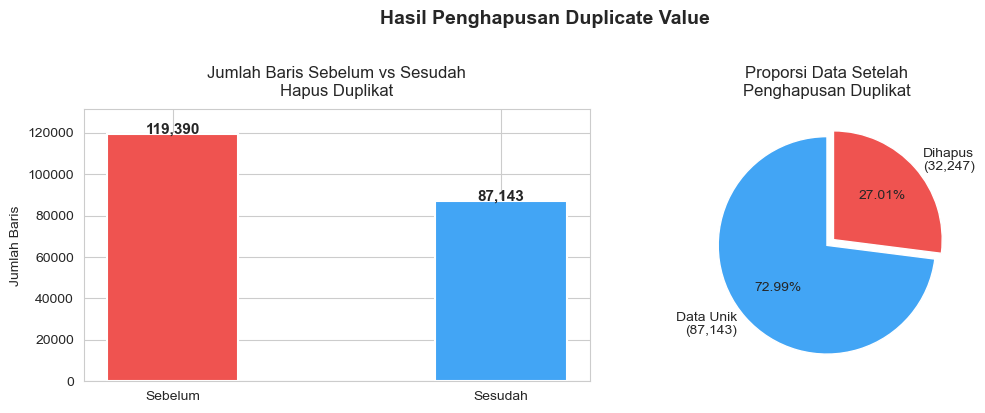

In [5]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels = ['Sebelum', 'Sesudah']
values = [sebelum, sesudah]
colors = ['#EF5350', '#42A5F5']

bars = axes[0].bar(labels, values, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Baris Sebelum vs Sesudah\nHapus Duplikat', fontsize=12, pad=10)
axes[0].set_ylabel('Jumlah Baris')
axes[0].set_ylim(0, sebelum * 1.1)

sizes = [sesudah, sebelum - sesudah]
pie_labels = [f'Data Unik\n({sesudah:,})', f'Dihapus\n({sebelum - sesudah:,})']
axes[1].pie(sizes, labels=pie_labels, autopct='%1.2f%%',
            colors=['#42A5F5', '#EF5350'], startangle=90,
            explode=[0, 0.08], textprops={'fontsize': 10})
axes[1].set_title('Proporsi Data Setelah\nPenghapusan Duplikat', fontsize=12, pad=10)

plt.suptitle('Hasil Penghapusan Duplicate Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Penanganan Missing Value

Setiap kolom yang masih memiliki missing value ditangani dengan strategi berbeda:
- `children` → isi dengan **0** (asumsi tidak ada anak jika tidak disebutkan)
- `agent` → isi dengan **0** (asumsi pemesanan langsung tanpa agen)
- `country` → isi dengan **modus** (negara paling umum)

In [7]:
print("Missing value sebelum penanganan:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# children: isi 0
df['children'] = df['children'].fillna(0).astype(int)

# agent: isi 0 (tanpa agen)
df['agent'] = df['agent'].fillna(0).astype(int)

# country: isi modus
modus_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(modus_country)

print("\nMissing value sesudah penanganan:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nTidak ada missing value tersisa." if df.isnull().sum().sum() == 0 else "⚠ Masih ada missing value.")

Missing value sebelum penanganan:
Series([], dtype: int64)

Missing value sesudah penanganan:
Series([], dtype: int64)

Tidak ada missing value tersisa.


## 7. Visualisasi Missing Value Sebelum vs Sesudah Penanganan

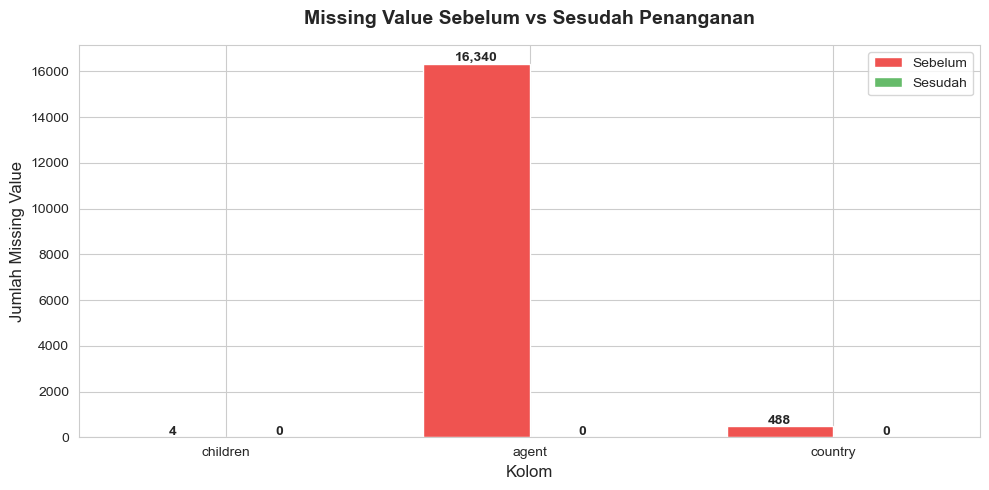

In [8]:
missing_cols = ['children', 'agent', 'country']
before_vals  = [4, 16340, 488]
after_vals   = [df[c].isnull().sum() for c in missing_cols]

x = np.arange(len(missing_cols))
width = 0.35

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, before_vals, width, label='Sebelum', color='#EF5350', edgecolor='white')
bars2 = ax.bar(x + width/2, after_vals,  width, label='Sesudah', color='#66BB6A', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{int(bar.get_height())}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Missing Value Sebelum vs Sesudah Penanganan', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kolom', fontsize=12)
ax.set_ylabel('Jumlah Missing Value', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(missing_cols)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Penanganan Inconsistent Value

Dari EDA ditemukan nilai `Undefined` pada kolom `meal` dan `market_segment`.
Nilai `Undefined` pada `meal` diganti dengan `SC` (Self Catering / tanpa paket makan).
Nilai `Undefined` pada `market_segment` diganti dengan `Direct`.

In [9]:
print("Nilai unik meal sebelum:", df['meal'].unique())
print("Nilai unik market_segment sebelum:", df['market_segment'].unique())

df['meal'] = df['meal'].replace('Undefined', 'SC')
df['market_segment'] = df['market_segment'].replace('Undefined', 'Direct')

print("\nNilai unik meal sesudah:", df['meal'].unique())
print("Nilai unik market_segment sesudah:", df['market_segment'].unique())

Nilai unik meal sebelum: <ArrowStringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str
Nilai unik market_segment sebelum: <ArrowStringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',     'Undefined',      'Aviation']
Length: 8, dtype: str

Nilai unik meal sesudah: <ArrowStringArray>
['BB', 'FB', 'HB', 'SC']
Length: 4, dtype: str
Nilai unik market_segment sesudah: <ArrowStringArray>
[       'Direct',     'Corporate',     'Online TA', 'Offline TA/TO',
 'Complementary',        'Groups',      'Aviation']
Length: 7, dtype: str


## 9. Visualisasi Distribusi Meal dan Market Segment Sesudah Penanganan

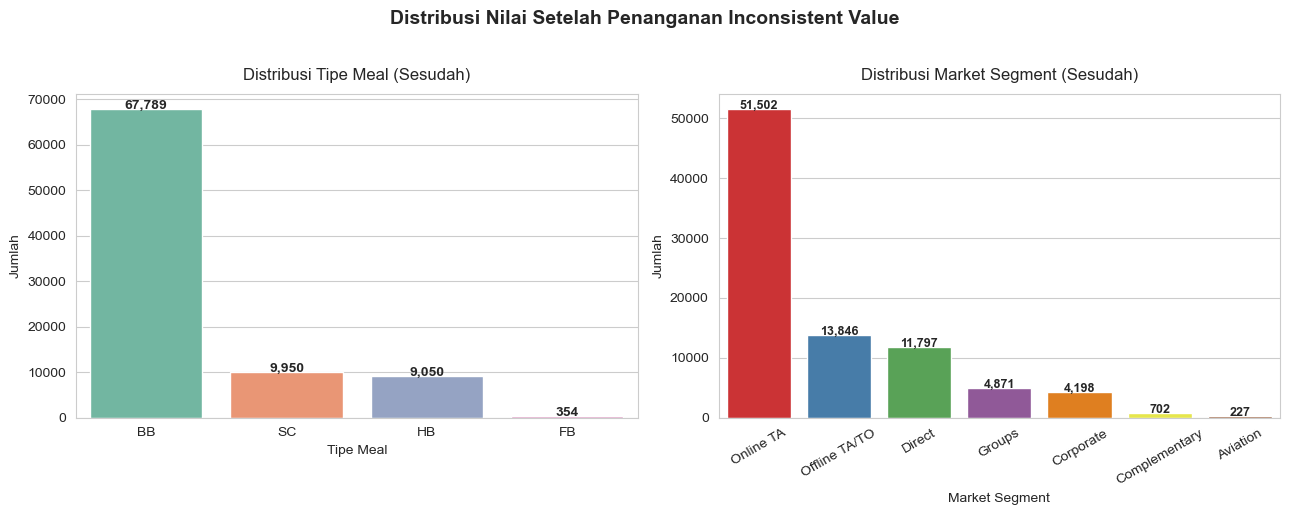

In [10]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Meal
meal_counts = df['meal'].value_counts().reset_index()
meal_counts.columns = ['Meal', 'Jumlah']
bars = sns.barplot(data=meal_counts, x='Meal', y='Jumlah', palette='Set2', ax=axes[0])
for bar, val in zip(bars.patches, meal_counts['Jumlah']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
              f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribusi Tipe Meal (Sesudah)', fontsize=12, pad=10)
axes[0].set_xlabel('Tipe Meal')
axes[0].set_ylabel('Jumlah')

# Market Segment
seg_counts = df['market_segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Jumlah']
bars2 = sns.barplot(data=seg_counts, x='Segment', y='Jumlah', palette='Set1', ax=axes[1])
for bar, val in zip(bars2.patches, seg_counts['Jumlah']):
    bars2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
               f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Distribusi Market Segment (Sesudah)', fontsize=12, pad=10)
axes[1].set_xlabel('Market Segment')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Distribusi Nilai Setelah Penanganan Inconsistent Value',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Penanganan Outlier pada Kolom `adr`

Dari EDA, kolom `adr` (Average Daily Rate) memiliki nilai maksimum ekstrem (€5.400) dan ada nilai negatif yang tidak wajar.
Outlier ditangani menggunakan metode **IQR (Interquartile Range)**.

In [13]:
print(f"ADR sebelum - Min: {df['adr'].min():.2f}, Max: {df['adr'].max():.2f}, Mean: {df['adr'].mean():.2f}")
print(f"Jumlah ADR negatif: {(df['adr'] < 0).sum()}")

Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

outlier_adr = ((df['adr'] < batas_bawah) | (df['adr'] > batas_atas)).sum()
df = df[(df['adr'] >= batas_bawah) & (df['adr'] <= batas_atas)]
df.reset_index(drop=True, inplace=True)

print(f"\nQ1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Batas bawah: {batas_bawah:.2f} | Batas atas: {batas_atas:.2f}")
print(f"Jumlah outlier dihapus: {outlier_adr:,}")
print(f"ADR sesudah - Min: {df['adr'].min():.2f}, Max: {df['adr'].max():.2f}, Mean: {df['adr'].mean():.2f}")
print(f"Shape setelah hapus outlier ADR: {df.shape}")

ADR sebelum - Min: -6.38, Max: 227.00, Mean: 101.80
Jumlah ADR negatif: 1

Q1=71.10, Q3=130.00, IQR=58.90
Batas bawah: -17.25 | Batas atas: 218.35
Jumlah outlier dihapus: 626
ADR sesudah - Min: -6.38, Max: 218.33, Mean: 100.90
Shape setelah hapus outlier ADR: (84032, 30)


## 11. Visualisasi Distribusi ADR Sebelum vs Sesudah Penanganan Outlier

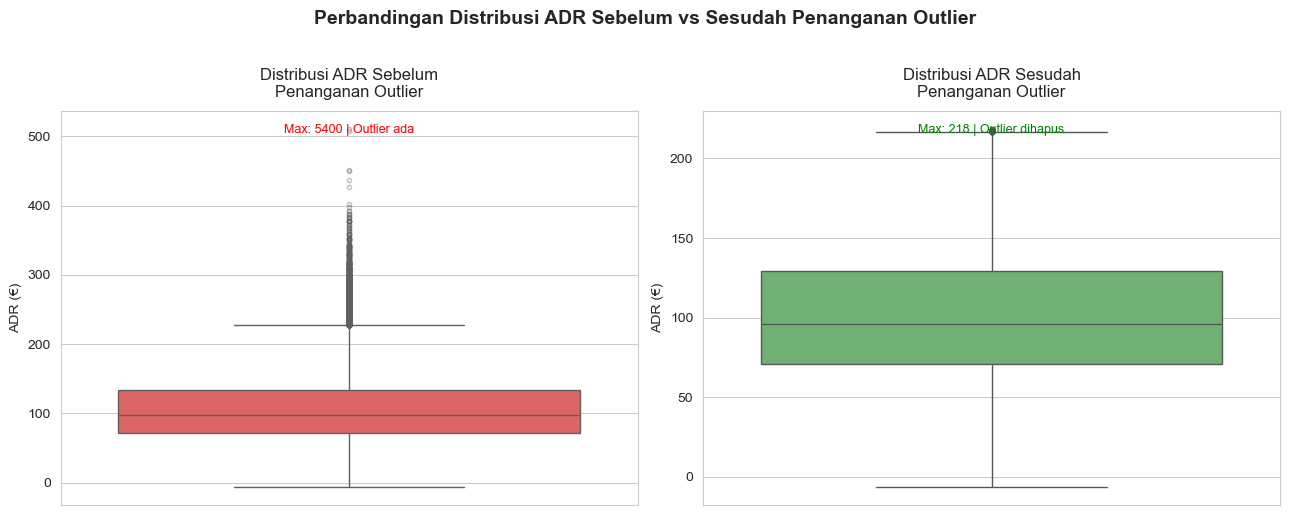

In [15]:
df_raw_adr = pd.read_csv("../data/raw/hotel_bookings.csv")
df_raw_adr.drop_duplicates(inplace=True)

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sebelum (filtered for display, not for removal)
sns.boxplot(y=df_raw_adr['adr'][df_raw_adr['adr'] < 600],
            ax=axes[0], color='#EF5350', flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[0].set_title('Distribusi ADR Sebelum\nPenanganan Outlier', fontsize=12, pad=10)
axes[0].set_ylabel('ADR (€)')
axes[0].text(0.5, 0.97, f"Max: {df_raw_adr['adr'].max():.0f} | Outlier ada",
             ha='center', va='top', transform=axes[0].transAxes, fontsize=9, color='red')

# Sesudah
sns.boxplot(y=df['adr'], ax=axes[1], color='#66BB6A',
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('Distribusi ADR Sesudah\nPenanganan Outlier', fontsize=12, pad=10)
axes[1].set_ylabel('ADR (€)')
axes[1].text(0.5, 0.97, f"Max: {df['adr'].max():.0f} | Outlier dihapus",
             ha='center', va='top', transform=axes[1].transAxes, fontsize=9, color='green')

plt.suptitle('Perbandingan Distribusi ADR Sebelum vs Sesudah Penanganan Outlier',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Penanganan Outlier pada Kolom `lead_time`

Dari EDA, `lead_time` memiliki distribusi *right-skewed* dengan nilai maksimum 737 hari.
Outlier ditangani menggunakan metode **IQR**.

In [16]:
print(f"Lead time sebelum - Min: {df['lead_time'].min()}, Max: {df['lead_time'].max()}, Mean: {df['lead_time'].mean():.2f}")

Q1_lt = df['lead_time'].quantile(0.25)
Q3_lt = df['lead_time'].quantile(0.75)
IQR_lt = Q3_lt - Q1_lt
batas_bawah_lt = Q1_lt - 1.5 * IQR_lt
batas_atas_lt  = Q3_lt + 1.5 * IQR_lt

outlier_lt = ((df['lead_time'] < batas_bawah_lt) | (df['lead_time'] > batas_atas_lt)).sum()
df = df[(df['lead_time'] >= batas_bawah_lt) & (df['lead_time'] <= batas_atas_lt)]
df.reset_index(drop=True, inplace=True)

print(f"Q1={Q1_lt:.0f}, Q3={Q3_lt:.0f}, IQR={IQR_lt:.0f}")
print(f"Batas bawah: {batas_bawah_lt:.0f} | Batas atas: {batas_atas_lt:.0f}")
print(f"Jumlah outlier dihapus: {outlier_lt:,}")
print(f"Lead time sesudah - Min: {df['lead_time'].min()}, Max: {df['lead_time'].max()}, Mean: {df['lead_time'].mean():.2f}")
print(f"Shape setelah hapus outlier lead_time: {df.shape}")

Lead time sebelum - Min: 0, Max: 737, Mean: 80.05
Q1=11, Q3=125, IQR=114
Batas bawah: -160 | Batas atas: 296
Jumlah outlier dihapus: 2,326
Lead time sesudah - Min: 0, Max: 296, Mean: 72.31
Shape setelah hapus outlier lead_time: (81706, 30)
